In [1]:
import pandas as pd
import numpy as np

# 先讀進模擬資料
# data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\embedding_data.csv")

data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\B\raw_data.csv")

cols = data.columns[:-1].to_list() 

whole = data.copy()

data = whole.iloc[0:35,:]

# data[cols] = (data[cols] - data[cols].mean()) / data[cols].std() # 針對變數標準化，後面做softmax的時候，數值才不會爆掉

validation = whole.iloc[35:50,:]

# validation[cols] = (validation[cols] - validation[cols].mean()) / validation[cols].std()

# ### 先用傳統統計模型驗證
X = data[cols]

# XTX = X.T @ X

y = data["Y"]

In [ ]:
# pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F

def train_attention_model(X, y, epochs=1000, lr=0.001):

    if isinstance(X, pd.DataFrame): 
        X = torch.tensor(
            X.values,
            dtype=torch.float32
        )

    if isinstance(y, pd.Series):
        y = torch.tensor(
            y.values,
            dtype=torch.float32
        )

    N = X.shape[0]
    P = X.shape[1]

    dk = 4
    embedding_dim = len(X)

    wq = torch.randn(
        dk,
        embedding_dim,
        requires_grad=True
    )

    wk = torch.randn(
        dk,
        embedding_dim,
        requires_grad=True
    )


    optimizer = torch.optim.Adam(
        [wq,wk],
        lr=lr
    )


    lam = 1

    I = torch.eye(
        P,
        dtype=X.dtype
    )


    for epoch in range(epochs):

        E = X

        Q = wq @ E
        K = wk @ E


        scores = K.T @ Q
        scores = scores / np.sqrt(dk)


        attn = F.softmax(
            scores,
            dim=0
        )


        A = attn @ attn.T + lam*I


        beta = torch.linalg.solve(
            X.T@X + A,
            X.T@y
        )


        y_hat = X@beta


        loss = F.mse_loss(
            y_hat,
            y
        )


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():

        E = X

        Q = wq @ E
        K = wk @ E

        scores = K.T @ Q
        scores = scores / np.sqrt(dk)

        final_attn = F.softmax(
            scores,
            dim=0
        )

        A = final_attn @ final_attn.T + lam*I

        adaptive_matrix = A

        final_beta = torch.linalg.solve(
            X.T@X + A,
            X.T@y
        )


    return (
        final_beta.detach(),
        final_attn.detach(),
        adaptive_matrix.detach()
    )

In [3]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from tqdm import tqdm

n_repeat = 100

beta_results = []
mse_results = []
rmse_results = []
r2_results = []
attention_results = []
adaptive_results = []

for seed in tqdm(range(n_repeat), desc="Simulation"):

    torch.manual_seed(seed)
    np.random.seed(seed)


    beta_attn, attn_matrix, adaptive_matrix = train_attention_model(
        X,
        y
    )


    beta_results.append(
        beta_attn.numpy()
    )

    attention_results.append(
        attn_matrix.numpy()
    )

    adaptive_results.append(
    adaptive_matrix.numpy()
    )


    # validation

    X_val = validation[cols].values

    y_pred = (
        torch.tensor(
            X_val,
            dtype=torch.float32
        )
        @ beta_attn
    ).numpy()

    y_val = validation["Y"].values

    mse = mean_squared_error(
        y_val,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_val,
        y_pred
    )


    mse_results.append(mse)
    rmse_results.append(rmse)
    r2_results.append(r2)

Simulation: 100%|██████████| 100/100 [01:39<00:00,  1.01it/s]


In [4]:
beta_results = np.array(beta_results)

beta_mean = beta_results.mean(axis=0)

beta_sd = beta_results.std(axis=0)

In [5]:
# 用套件驗證OLS
import statsmodels.api as sm

X = data[cols]

model = sm.OLS(
    data["Y"],
    X          # 不加 constant
)

result = model.fit()

beta_ols = result.params.values

y_pred_ols = X_val @ beta_ols

mse_ols = mean_squared_error(
    y_val,
    y_pred_ols
)

rmse_ols = np.sqrt(mse_ols)

ols_r2 = r2_score(y_val, y_pred_ols)

In [7]:
# Ridge
from sklearn.linear_model import Ridge
# ======================
# Split X and Y
# ======================

X_train = data[cols].values
y_train = data["Y"].values

# ======================
# Ridge model
# ======================

ridge = Ridge(alpha=1.0, fit_intercept=False)

ridge.fit(
    X_train,
    y_train,
)

beta_ridge = ridge.coef_

y_pred_ridge = X_val @ beta_ridge

mse_ridge = mean_squared_error(
    y_val,
    y_pred_ridge
)

rmse_ridge = np.sqrt(mse_ridge)

ridge_r2 = r2_score(y_val, y_pred_ridge)

In [8]:
# 模擬資料生成時的實際係數
true_beta = pd.read_csv(
    r"C:\Users\USER\Desktop\碩論\程式碼\B\true_beta.csv"
)

beta_true = true_beta["True_beta"].values
ols_bias = abs(beta_ols - beta_true)
attn_bias = abs(beta_mean - beta_true) # 平均係數
ridge_bias = abs(beta_ridge - beta_true)

In [9]:
beta_summary = pd.DataFrame({

    "Variable":cols,

    "Beta_mean(DeepGLM)":beta_mean,

    "Beta_SD(DeepGLM)":beta_sd,

    "OLS":result.params,

    "Ridge":beta_ridge,

    "Simulation": beta_true

})


print(beta_summary)
print(f"OLS的係數偏差:{ols_bias.sum():.6f}")
print(f"Ridge的係數偏差:{ridge_bias.sum():.6f}")
print(f"DeepGLM的平均係數偏差:{attn_bias.sum():.6f}")

    Variable  Beta_mean(DeepGLM)  Beta_SD(DeepGLM)       OLS     Ridge  \
X1        X1            0.833380          0.284810  1.635490  0.958468   
X2        X2            1.032960          0.283697  0.237266  0.914536   
X3        X3            0.928515          0.260032 -1.060083  0.929475   
X4        X4            0.955576          0.259890  2.988039  0.961210   
X5        X5            0.015302          0.018424  1.066174  0.027232   
X6        X6            0.066158          0.017534 -0.933764  0.056189   
X7        X7            0.224135          0.062402  2.651680  0.149983   
X8        X8            0.000034          0.064576 -2.423137  0.078081   
X9        X9           -0.035748          0.075258 -3.665030  0.042250   
X10      X10            0.215335          0.072634  3.820952  0.142533   

     Simulation  
X1          1.0  
X2          0.8  
X3          1.0  
X4          0.8  
X5          0.0  
X6          0.0  
X7          0.0  
X8          0.0  
X9          0.0  
X10  

In [10]:
metric_summary = pd.DataFrame({

    "Metric":[
        "MSE",
        "RMSE",
        "R2",
    ],

    "Mean(DeepGLM)":[
        np.mean(mse_results),
        np.mean(rmse_results),
        np.mean(r2_results)
    ],

    "SD(DeepGLM)":[
        np.std(mse_results),
        np.std(rmse_results),
        np.std(r2_results)
    ],

    "OLS":[
        mse_ols,
        rmse_ols,
        ols_r2
    ],

    "Ridge":[
        mse_ridge,
        rmse_ridge,
        ridge_r2
    ]

})


print(metric_summary)

  Metric  Mean(DeepGLM)  SD(DeepGLM)       OLS     Ridge
0    MSE       0.798354     0.006807  0.844377  0.804461
1   RMSE       0.893499     0.003806  0.918900  0.896918
2     R2       0.764231     0.002010  0.750640  0.762428


In [11]:
attention_results = np.array(attention_results)

attention_mean = attention_results.mean(axis=0)

attention_sd = attention_results.std(axis=0)

attention_summary = pd.DataFrame(
    index=cols,
    columns=cols
)

for i in range(len(cols)):
    for j in range(len(cols)):

        attention_summary.iloc[i,j] = (
            f"{attention_mean[i,j]:.4f}"
            " ± "
            f"{attention_sd[i,j]:.4f}"
        )

print(attention_summary)

                  X1               X2               X3               X4  \
X1   0.0772 ± 0.2540  0.0781 ± 0.2540  0.0708 ± 0.2367  0.0689 ± 0.2364   
X2   0.0274 ± 0.1136  0.0287 ± 0.1161  0.0323 ± 0.1203  0.0319 ± 0.1202   
X3   0.0210 ± 0.0589  0.0205 ± 0.0589  0.0422 ± 0.1737  0.0424 ± 0.1746   
X4   0.0549 ± 0.1956  0.0542 ± 0.1953  0.0465 ± 0.1957  0.0462 ± 0.1956   
X5   0.1448 ± 0.2883  0.1441 ± 0.2868  0.1768 ± 0.2998  0.1772 ± 0.3007   
X6   0.0607 ± 0.1396  0.0613 ± 0.1404  0.0918 ± 0.1686  0.0925 ± 0.1697   
X7   0.0626 ± 0.0898  0.0633 ± 0.0921  0.0557 ± 0.0936  0.0552 ± 0.0937   
X8   0.3093 ± 0.3829  0.3061 ± 0.3787  0.2593 ± 0.3577  0.2592 ± 0.3609   
X9   0.1998 ± 0.3234  0.2003 ± 0.3249  0.1685 ± 0.3003  0.1699 ± 0.3024   
X10  0.0422 ± 0.0829  0.0434 ± 0.0850  0.0560 ± 0.1309  0.0566 ± 0.1316   

                  X5               X6               X7               X8  \
X1   0.0887 ± 0.2689  0.0886 ± 0.2690  0.0813 ± 0.2690  0.0809 ± 0.2690   
X2   0.0374 ± 0.1490  0.

In [12]:
adaptive_results = np.array(adaptive_results)

adaptive_mean = adaptive_results.mean(axis=0)

adaptive_sd = adaptive_results.std(axis=0)

adaptive_summary = pd.DataFrame(
    index=cols,
    columns=cols
)

for i in range(len(cols)):
    for j in range(len(cols)):
        adaptive_summary.iloc[i,j] = (
            f"{adaptive_mean[i,j]:.4f}"
            " ± "
            f"{adaptive_sd[i,j]:.4f}"
        )

print(adaptive_summary)

                  X1               X2               X3               X4  \
X1   1.8192 ± 1.4294  0.0137 ± 0.0187  0.0000 ± 0.0003  0.0001 ± 0.0005   
X2   0.0137 ± 0.0187  1.1554 ± 0.6116  0.0003 ± 0.0020  0.0003 ± 0.0023   
X3   0.0000 ± 0.0003  0.0003 ± 0.0020  1.3385 ± 0.8841  0.0212 ± 0.0258   
X4   0.0001 ± 0.0005  0.0003 ± 0.0023  0.0212 ± 0.0258  1.3694 ± 1.0198   
X5   0.0014 ± 0.0061  0.0014 ± 0.0074  0.0082 ± 0.0378  0.0025 ± 0.0090   
X6   0.0006 ± 0.0023  0.0006 ± 0.0029  0.0012 ± 0.0040  0.0008 ± 0.0027   
X7   0.0017 ± 0.0054  0.0021 ± 0.0050  0.0011 ± 0.0034  0.0016 ± 0.0056   
X8   0.0279 ± 0.0737  0.0692 ± 0.1727  0.0158 ± 0.0512  0.0193 ± 0.0554   
X9   0.0158 ± 0.0595  0.0280 ± 0.1077  0.0990 ± 0.1743  0.0498 ± 0.0917   
X10  0.0017 ± 0.0087  0.0025 ± 0.0134  0.0062 ± 0.0138  0.0040 ± 0.0089   

                  X5               X6               X7               X8  \
X1   0.0014 ± 0.0061  0.0006 ± 0.0023  0.0017 ± 0.0054  0.0279 ± 0.0737   
X2   0.0014 ± 0.0074  0.

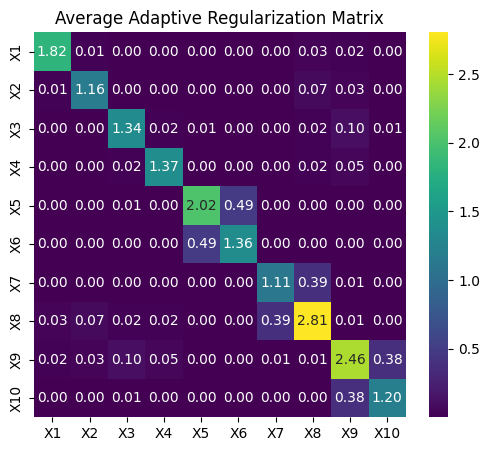

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    adaptive_mean,
    xticklabels=cols,
    yticklabels=cols,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Average Adaptive Regularization Matrix")
plt.show()